In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

df = pd.read_json("/Users/dorageeraerts/Documents/PhD/software/muraves/RECO_data/NERO/v1/MURAVES_AnalyzedData_run5747.jsonl", lines=True)

In [3]:
print(df.shape)

(40000, 148)


In [4]:
print(df.iloc[0].to_dict())

{'Run': 5747, 'Nclusters_Z1': 2, 'Nclusters_Z2': 0, 'Nclusters_Z3': 1, 'Nclusters_Z4': 0, 'Nclusters_Y1': 1, 'Nclusters_Y2': 1, 'Nclusters_Y3': 1, 'Nclusters_Y4': 1, 'ClusterSize_Z1': [2, 1], 'ClusterSize_Z2': [], 'ClusterSize_Z3': [2], 'ClusterSize_Z4': [], 'ClusterZ1_Texp': [629.0, 478.0], 'ClusterZ2_Texp': [], 'ClusterZ3_Texp': [557.0], 'ClusterZ4_Texp': [], 'ClusterEnergy_Z1': [37.914438502673804, 10.818181818181818], 'ClusterEnergy_Z2': [], 'ClusterEnergy_Z3': [23.205882352941174], 'ClusterEnergy_Z4': [], 'ClusterPosition_Z1': [0.48973815232722107, -0.137], 'ClusterPosition_Z2': [], 'ClusterPosition_Z3': [-0.24057794676806002], 'ClusterPosition_Z4': [], 'ClusterSize_Y1': [2], 'ClusterSize_Y2': [1], 'ClusterSize_Y3': [2], 'ClusterSize_Y4': [1], 'ClusterY1_Texp': [578.0], 'ClusterY2_Texp': [651.0], 'ClusterY3_Texp': [628.0], 'ClusterY4_Texp': [0.0], 'ClusterEnergy_Y1': [41.90909090909091], 'ClusterEnergy_Y2': [13.492307692307692], 'ClusterEnergy_Y3': [30.30625], 'ClusterEnergy_Y4': 

In [5]:
print(df.columns.tolist())

['Run', 'Nclusters_Z1', 'Nclusters_Z2', 'Nclusters_Z3', 'Nclusters_Z4', 'Nclusters_Y1', 'Nclusters_Y2', 'Nclusters_Y3', 'Nclusters_Y4', 'ClusterSize_Z1', 'ClusterSize_Z2', 'ClusterSize_Z3', 'ClusterSize_Z4', 'ClusterZ1_Texp', 'ClusterZ2_Texp', 'ClusterZ3_Texp', 'ClusterZ4_Texp', 'ClusterEnergy_Z1', 'ClusterEnergy_Z2', 'ClusterEnergy_Z3', 'ClusterEnergy_Z4', 'ClusterPosition_Z1', 'ClusterPosition_Z2', 'ClusterPosition_Z3', 'ClusterPosition_Z4', 'ClusterSize_Y1', 'ClusterSize_Y2', 'ClusterSize_Y3', 'ClusterSize_Y4', 'ClusterY1_Texp', 'ClusterY2_Texp', 'ClusterY3_Texp', 'ClusterY4_Texp', 'ClusterEnergy_Y1', 'ClusterEnergy_Y2', 'ClusterEnergy_Y3', 'ClusterEnergy_Y4', 'ClusterPosition_Y1', 'ClusterPosition_Y2', 'ClusterPosition_Y3', 'ClusterPosition_Y4', 'StripsEnergy_Z1', 'StripsEnergy_Z2', 'StripsEnergy_Z3', 'StripsEnergy_Z4', 'StripsEnergy_Y1', 'StripsEnergy_Y2', 'StripsEnergy_Y3', 'StripsEnergy_Y4', 'StripsPosition_Z1', 'StripsPosition_Z2', 'StripsPosition_Z3', 'StripsPosition_Z4', 'Str

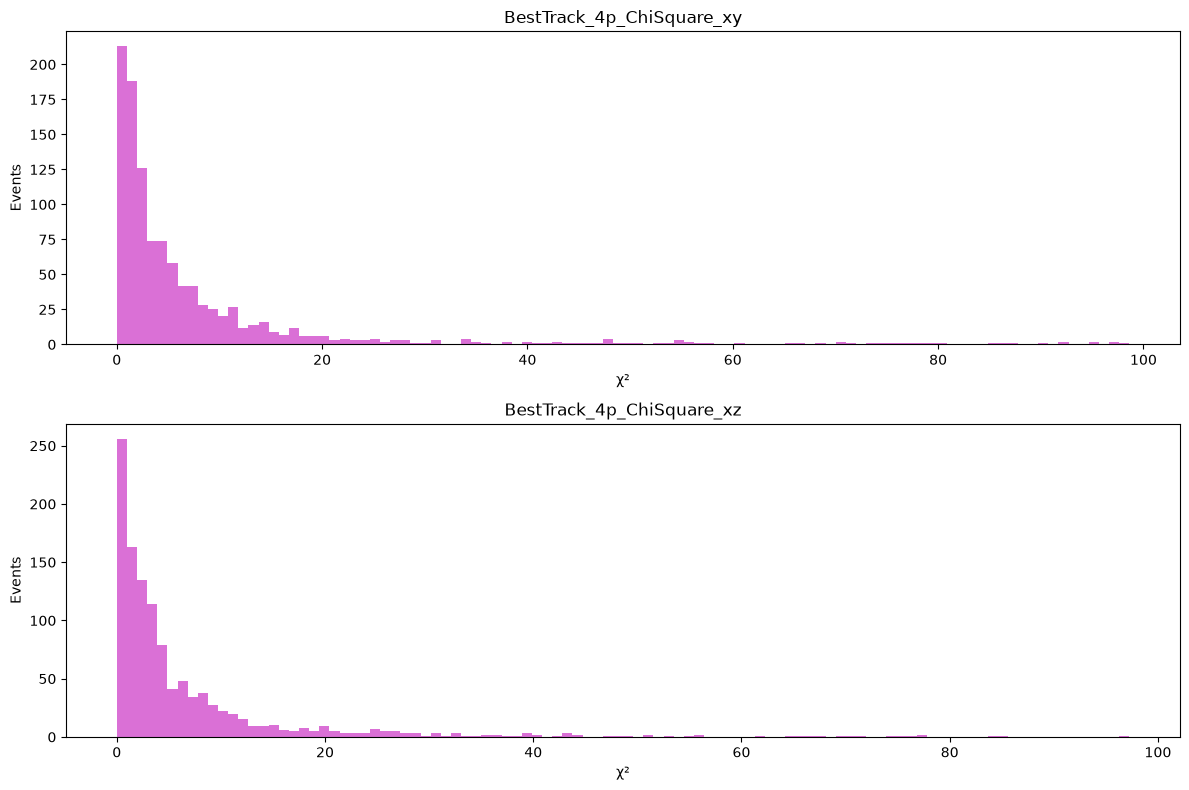

In [27]:
columns = [
    "BestTrack_4p_ChiSquare_xy",
    "BestTrack_4p_ChiSquare_xz",
]


fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, col in zip(axes.flat, columns):

    values = df[col].dropna()
    values = values[(values >= 0) & (values <= 100)]

    ax.hist(values, bins=100, color="orchid")

    ax.set_title(col)
    ax.set_xlabel("χ²")
    ax.set_ylabel("Events")

plt.tight_layout()
plt.show()

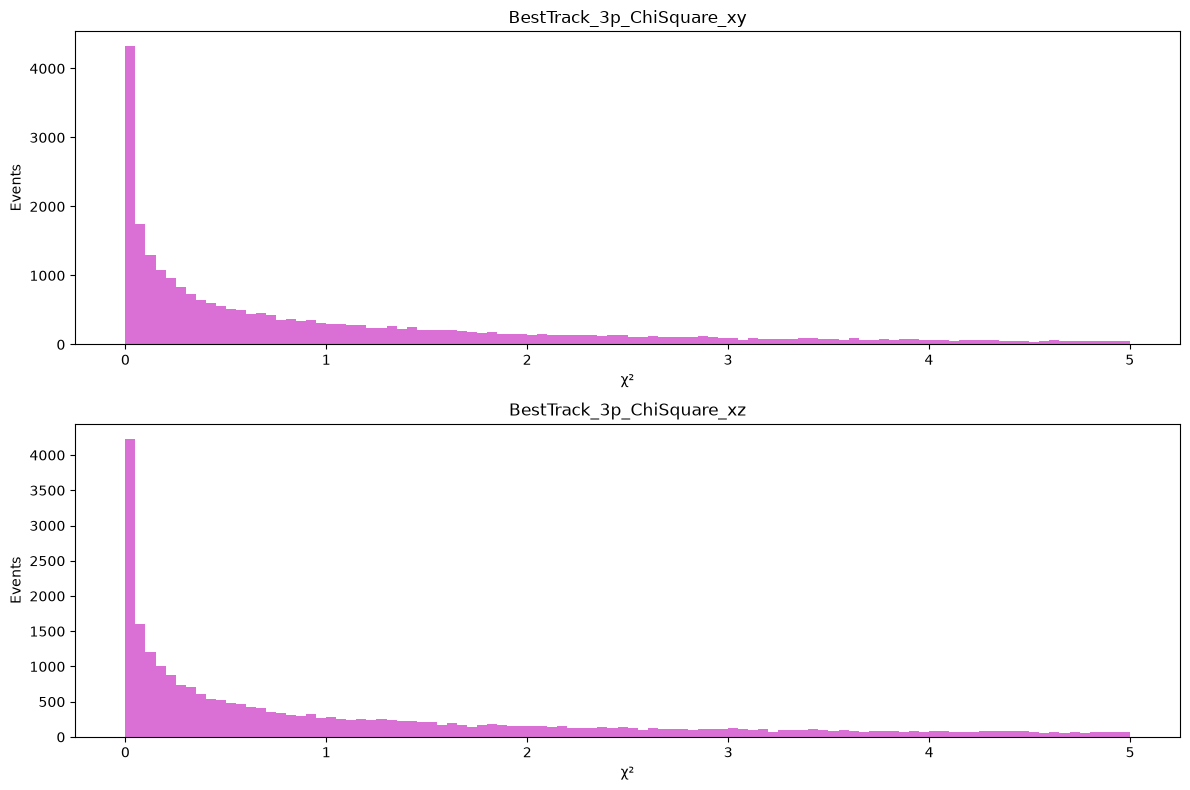

In [20]:
columns = [
    "BestTrack_3p_ChiSquare_xy",
    "BestTrack_3p_ChiSquare_xz",
]


fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, col in zip(axes.flat, columns):

    values = df[col].dropna()
    values = values[(values >= 0) & (values <= 5)]

    ax.hist(values, bins=100, color="orchid")

    ax.set_title(col)
    ax.set_xlabel("χ²")
    ax.set_ylabel("Events")

plt.tight_layout()
plt.show()

In [31]:
threshold = 2

df_selected = df[
    (df["BestTrack_4p_ChiSquare_xy"] >= 0) &  # filter out chi2=-1
    (df["BestTrack_4p_ChiSquare_xy"] < threshold) &
    (df["BestTrack_4p_ChiSquare_xz"] >= 0) &
    (df["BestTrack_4p_ChiSquare_xz"] < threshold)
]

print("Original:", len(df))
print("Selected:", len(df_selected))

Original: 40000
Selected: 147
